# Library imports and setting file path

In [9]:
import os
import sys
import warnings
import pandas as pd
import geopandas as gpd

ROOT = os.path.abspath(".")
PY_SCRIPTS = os.path.join(ROOT, "py_scripts")
sys.path.insert(0, PY_SCRIPTS)

from parse_adjacency import parse_adjacency, load_adjacency
from parse_county_data import parse_county_data, load_county_data
from min_coverage import solve_min_coverage
from equitable_placement import solve_equitable
from helper_functions import STATE_FIPS_TO_NAME, plot_centers


SHP_PATH = os.path.join(ROOT, "county_data", "cb_2023_us_county_500k", "cb_2023_us_county_500k.shp")
DEMO_PATH = os.path.join(ROOT, "county_data", "county_demographics.csv")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# User defines desired state of interest and k value for equitable placement model

In [10]:
STATE_NAME = "Massachusetts"
STATE_FIPS = {name: fips for fips, name in STATE_FIPS_TO_NAME.items()}[STATE_NAME]

k = 10

# Parse adjacency and county data

In [11]:
parse_adjacency(STATE_FIPS)
parse_county_data(DEMO_PATH, STATE_FIPS)
adj = load_adjacency(STATE_FIPS)
cdata = load_county_data(STATE_FIPS)

# Load shapefile and filter to desired state

In [12]:
shp = gpd.read_file(SHP_PATH)
state_shp = shp[shp["STATEFP"] == STATE_FIPS].copy()
if state_shp.empty:
    raise ValueError("No counties after filter (check STATE_FIPS / STATE_NAME).")
state_shp = state_shp.to_crs(state_shp.estimate_utm_crs())

# Solve Minimum Coverage Problem

Min coverage: 5 centers, objective 5.0, 0.0003s


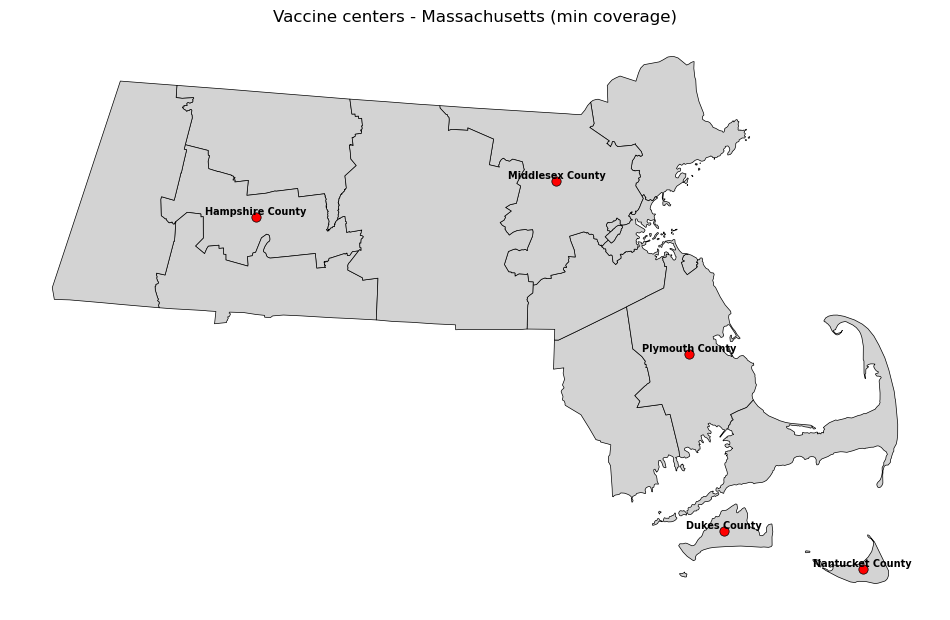

In [13]:
centers_a, obj_a, time_a = solve_min_coverage(adj, cdata)
print(f"Min coverage: {len(centers_a)} centers, objective {obj_a}, {time_a:.4f}s")
plot_centers(state_shp, cdata, centers_a, "min coverage")

In [14]:
df_a = pd.DataFrame(
    [
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_a,
        }
        for fips, data in cdata.items()
    ]
)
display(df_a)

,FIPS,County,Population,Is_Center
0,25001,Barnstable County,233539,False
1,25003,Berkshire County,128224,False
2,25005,Bristol County,593640,False
3,25007,Dukes County,21219,True
4,25009,Essex County,826653,False
5,25011,Franklin County,70698,False
6,25013,Hampden County,464338,False
7,25015,Hampshire County,164065,True
8,25017,Middlesex County,1669979,True
9,25019,Nantucket County,14758,True


# Solve Equitable Placement Problem

Equitable (k=10): 10 centers, objective 5621617.20, 0.0023s


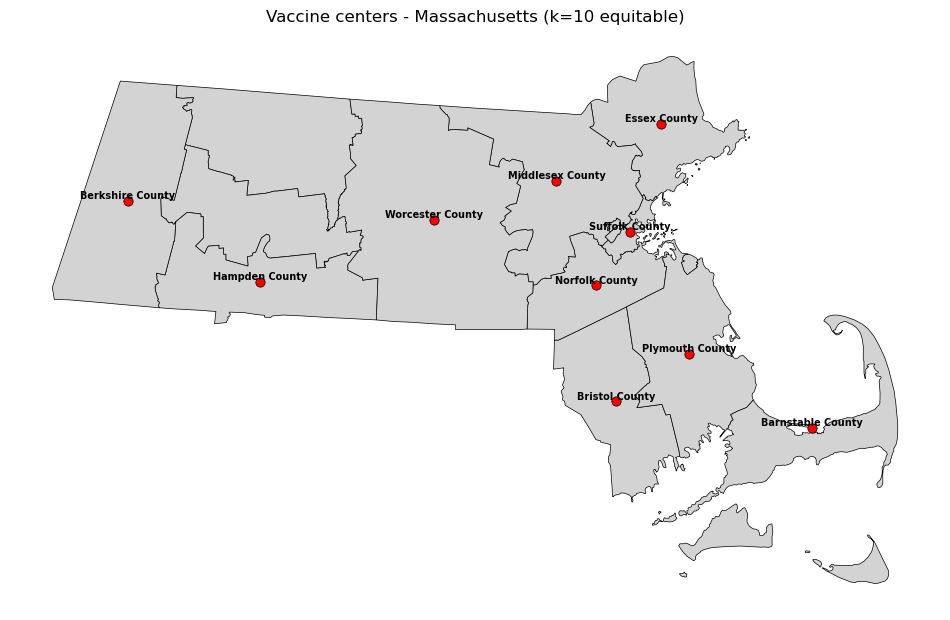

In [15]:
centers_b, obj_b, time_b, assigned = solve_equitable(cdata, k)
print(
    f"Equitable (k={k}): {len(centers_b)} centers, objective {obj_b:.2f}, {time_b:.4f}s"
)
plot_centers(state_shp, cdata, centers_b, f"k={k} equitable")

In [16]:
df_b = pd.DataFrame(
    [
        {
            "FIPS": fips,
            "County": data["name"],
            "Population": data["population"],
            "Is_Center": fips in centers_b,
            "Assigned_To": assigned.get(fips),
        }
        for fips, data in cdata.items()
    ]
)
display(df_b)

,FIPS,County,Population,Is_Center,Assigned_To
0,25001,Barnstable County,233539,True,25001
1,25003,Berkshire County,128224,True,25003
2,25005,Bristol County,593640,True,25005
3,25007,Dukes County,21219,False,25005
4,25009,Essex County,826653,True,25009
5,25011,Franklin County,70698,False,25013
6,25013,Hampden County,464338,True,25013
7,25015,Hampshire County,164065,False,25013
8,25017,Middlesex County,1669979,True,25017
9,25019,Nantucket County,14758,False,25001
